In [1]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
import yaml
import re

print("Starting combined preprocessing script...")


# Define paths and parameters

data_path = r"C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 2"
processed_data_path = r"D:\Per Patient Normalization Output without the first 3 trials block 2"
os.makedirs(processed_data_path, exist_ok=True)
log_file = os.path.join(processed_data_path, "discrepancies_log.yaml")

# Time windows for epochs
iti_tmin, iti_tmax = -1.0, 0.0   # ITI: 1s before stimulus
stim_tmin, stim_tmax = 0.0, 4.5    # Stimulus: 0 to 4.5s after stimulus

# Expected markers
expected_stim_markers = {'23', '21', '22', '220', '210'}
expected_tms_markers = {'234', '214', '224'}


# Helper functions

def log_discrepancies(log_file, discrepancies):
    with open(log_file, "a") as f:
        yaml.dump(discrepancies, f)

def plot_data(data, title, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(data.T)
    plt.title(title)
    plt.xlabel("Time Points")
    plt.ylabel("Amplitude")
    plt.savefig(save_path)
    plt.close()

def clean_vmrk_file(input_path, output_path):
    """
    Cleans a .vmrk file by keeping only stimulus markers.
    """
    with open(input_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    cleaned_lines = []
    marker_pattern = re.compile(r"^Mk\d+=(Stimulus),(.+?),(\d+),(\d+),(\d+)(,.*)?$")
    process_markers = False

    for line in lines:
        if line.strip().startswith(";") or line.strip() == "" or line.strip().startswith("["):
            cleaned_lines.append(line)
            continue

        if line.strip().startswith("Mk2=DC Correction"):
            process_markers = True
            continue

        if process_markers and line.strip().startswith("Mk"):
            match = marker_pattern.match(line.strip())
            if match and match.group(2) in expected_stim_markers:
                marker_type = match.group(1)
                # Add 'S' prefix if not already present
                description = match.group(2)
                if not description.startswith("S"):
                    description = "S" + description
                position = match.group(3)
                size = match.group(4)
                channel = match.group(5)
                extra = match.group(6) or ""
                cleaned_lines.append(f"Mk{len(cleaned_lines)+1}={marker_type},{description},{position},{size},{channel}{extra}\n")
        else:
            print(f"Warning: Ignored invalid or non-stimulus marker line -> {line.strip()}")
    
    with open(output_path, 'w', encoding='utf-8') as file:
        file.writelines(cleaned_lines)
    print(f"Cleaned .vmrk file saved to {output_path}")


# Process each participant separately

files = os.listdir(data_path)
vhdr_files = [file for file in files if file.endswith('.vhdr')]
print(f"Found {len(vhdr_files)} .vhdr files: {vhdr_files}")

summary_data = []
summary_file = os.path.join(processed_data_path, "marker_summary.txt")

for vhdr_file in vhdr_files:
    # Use the file name (or a slightly modified version) as participant ID
    if vhdr_file == "01_ln_block1.vhdr":
        participant_block = "01_ln_block1"
    else:
        participant_block = os.path.splitext(vhdr_file)[0]
    
    print(f"\nProcessing file: {vhdr_file}")
    print(f"Participant block: {participant_block}")
    
    try:
        # Define file paths for .vhdr, .vmrk, and .eeg
        vhdr_path = os.path.join(data_path, vhdr_file)
        vmrk_path = os.path.join(data_path, participant_block + ".vmrk")
        eeg_path = os.path.join(data_path, participant_block + ".eeg")
        
        print(f"Checking files:\n{vhdr_path}\n{vmrk_path}\n{eeg_path}")
        if not all([os.path.exists(vhdr_path), os.path.exists(vmrk_path), os.path.exists(eeg_path)]):
            print(f"Skipping {vhdr_file}: One or more required files are missing!")
            continue
        
        # Extract markers from the .vmrk file
        markers = []
        with open(vmrk_path, 'r') as file:
            for line in file:
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    description = parts[1].strip()
                    sample = int(parts[2].strip())
                    markers.append((description, sample))
        if markers:
            print("Markers found:", markers)
        else:
            print("No stimulus markers found.")
        
        # Load the raw data (BrainVision format auto-links .vmrk and .eeg)
        raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
        events, event_id = mne.events_from_annotations(raw)
        
        # Filter events for stimulus markers
        stim_events = [event for event in events if str(event[2]) in expected_stim_markers]
        tms_events = [event for event in events if str(event[2]) in expected_tms_markers]
        
        stim_marker_counts = {marker: 0 for marker in expected_stim_markers}
        tms_marker_counts = {marker: 0 for marker in expected_tms_markers}
        for event in stim_events:
            marker = str(event[2])
            stim_marker_counts[marker] += 1
        for event in tms_events:
            marker = str(event[2])
            tms_marker_counts[marker] += 1
        
        print(f"Stimulus marker counts: {stim_marker_counts}")
        print(f"TMS marker counts: {tms_marker_counts}")
        
        if not stim_events:
            print(f"No stimulus markers found for {participant_block}. Skipping file.")
            continue
        
        # Build the events array for Epochs extraction.
        # Each row is: [sample, 0, event_id] where event_id is the marker code.
        stim_events_array = np.array([[event[0], 0, int(event[2])] for event in stim_events])
        
        
        # Remove the first three trials for each experimental condition
        
        unique_conditions = np.unique(stim_events_array[:, 2])
        keep_indices = []
        for cond in unique_conditions:
            cond_indices = np.where(stim_events_array[:, 2] == cond)[0]
            if len(cond_indices) > 3:
                keep_indices.extend(cond_indices[3:])  # Discard first 3 trials
            else:
                keep_indices.extend(cond_indices)
        keep_indices = np.sort(keep_indices)
        stim_events_array = stim_events_array[keep_indices]
        
        
        # Extract ITI epochs and stimulus epochs
        iti_epochs = mne.Epochs(raw, stim_events_array, None, tmin=iti_tmin, tmax=iti_tmax, baseline=None, preload=True)
        print(f"Extracted ITI epochs shape: {iti_epochs.get_data().shape}")
        
        stim_epochs = mne.Epochs(raw, stim_events_array, None, tmin=stim_tmin, tmax=stim_tmax, baseline=None, preload=True)
        print(f"Extracted stimulus epochs shape: {stim_epochs.get_data().shape}")
        
        # ----- STEP 1: ITI Subtraction (Channel-Specific) -----
        if iti_epochs.get_data().size > 0:
            iti_data = iti_epochs.get_data()    # Shape: (n_epochs, n_channels, n_times)
            stim_data = stim_epochs.get_data()    # Shape: (n_epochs, n_channels, n_times)
            # Compute per-channel ITI mean (averaging over epochs and time)
            iti_mean = iti_data.mean(axis=(0, 2), keepdims=True)  # Shape: (1, n_channels, 1)
            iti_subtracted_data = stim_data - iti_mean
            print("Performed ITI subtraction on stimulus data.")
        else:
            print("ITI data empty; skipping ITI subtraction.")
            iti_subtracted_data = stim_epochs.get_data()
        
        # ----- STEP 2: Standard Scaling on the ITI-Subtracted Data -----
        # Performing participant-wise normalization:
        # Compute a single global mean and standard deviation over all epochs, channels, and time points.
        mean_global = iti_subtracted_data.mean()
        std_global = iti_subtracted_data.std()
        normalized_stim_data = (iti_subtracted_data - mean_global) / std_global
        print("Applied participant-wise normalization on ITI-subtracted stimulus data.")
        
        # ----- Save Processed Data and Plots -----
        # Save normalized and raw stimulus data as .npy files
        np.save(os.path.join(processed_data_path, f"{participant_block}_normalized.npy"), normalized_stim_data)
        np.save(os.path.join(processed_data_path, f"{participant_block}_raw.npy"), stim_epochs.get_data())
        print(f"Saved normalized and raw data for {participant_block}.")
        
        # Plot ITI mean vs. stimulus mean (from raw data)
        iti_mean_plot = iti_epochs.get_data().mean(axis=(0, 2))
        stim_mean_plot = stim_epochs.get_data().mean(axis=(0, 2))
        plt.figure(figsize=(10, 5))
        plt.plot(iti_mean_plot, label='ITI Mean', color='blue')
        plt.plot(stim_mean_plot, label='Stimulus Mean', color='orange')
        plt.legend()
        plt.title("Comparison of ITI and Stimulus Means")
        plt.xlabel("Channels")
        plt.ylabel("Amplitude")
        plt.savefig(os.path.join(processed_data_path, f"{participant_block}_iti_vs_stim_means.png"))
        plt.close()
        
        # Plot first trial raw data
        plot_data(stim_epochs.get_data()[0], f"Raw Stimulus Data ({participant_block})",
                  os.path.join(processed_data_path, f"{participant_block}_raw.png"))
        # Plot first trial normalized data
        plot_data(normalized_stim_data[0], f"Normalized Stimulus Data ({participant_block})",
                  os.path.join(processed_data_path, f"{participant_block}_normalized.png"))
        print(f"Saved plots for {participant_block}.")
        
        # Append summary information
        summary_data.append({
            'Participant': participant_block,
            'Stimulus Markers': stim_marker_counts,
            'TMS Markers': tms_marker_counts,
            'Stimulus Data Shape': stim_epochs.get_data().shape,
            'Normalized Data Shape': normalized_stim_data.shape
        })
        
        with open(summary_file, 'w') as file:
            yaml.dump(summary_data, file)
        
    except Exception as e:
        print(f"Error processing {vhdr_file}: {e}")


Starting combined preprocessing script...
Found 30 .vhdr files: ['01_ln_block2.vhdr', '02gd_block2.vhdr', '03as_block2.vhdr', '04ep_block2.vhdr', '05br_block2.vhdr', '06_nc_block2.vhdr', '07fs_block2.vhdr', '08am_block2.vhdr', '09dm_block2.vhdr', '10lc_block2.vhdr', '11gb_block2.vhdr', '12ag_block2.vhdr', '13gc_block2.vhdr', '14es_block2.vhdr', '15kf_block2.vhdr', '16gd_block2.vhdr', '17st_block2.vhdr', '18gf_block2.vhdr', '19tm_block2.vhdr', '20md_block2.vhdr', '21es_block2.vhdr', '22mc_block2.vhdr', '23lp_block2.vhdr', '24cs_block2.vhdr', '25vt_block2.vhdr', '26fs_block2.vhdr', '27rv_block2.vhdr', '28gv_block2.vhdr', '29bc_block2.vhdr', '30ss_block2.vhdr']

Processing file: 01_ln_block2.vhdr
Participant block: 01_ln_block2
Checking files:
C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 2\01_ln_block2.vhdr
C:\Users\Asus\Documents\Professor Francesca Starita\raw_data_of_all_participants block 2\01_ln_block2.vmrk
C:\Users\Asus\Documents\Professor F

In [2]:
import os
import re
import numpy as np
import yaml
import matplotlib.pyplot as plt
from scipy.signal import iirfilter, sosfiltfilt

# Configuration
# Directory where the *_normalized.npy files live (post-ITI subtraction & scaling)
normalized_data_path = r"D:\Per Patient Normalization Output without the first 3 trials block 2"

# Directory to save final filtered/downsampled data
filtered_data_path = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2"
os.makedirs(filtered_data_path, exist_ok=True)

# Filter parameters
low_freq = 0.5    # Hz
high_freq = 50.0  # Hz
order = 4         # Butterworth order

# Original sampling rate *at the time this script runs* 
orig_sfreq = 5000  

# Downsampled rate
new_sfreq = 500    # Changed from 100 to 500 Hz
downsample_factor = orig_sfreq // new_sfreq  # Updated factor from 50 to 10

# Helper Functions

def bandpass_sos(low_hz, high_hz, order, fs):
    """
    Creates second-order sections for a Butterworth bandpass filter.
    fs: sampling rate (Hz)
    """
    from scipy.signal import iirfilter
    nyq = 0.5 * fs
    low  = low_hz / nyq
    high = high_hz / nyq
    sos = iirfilter(order, [low, high], btype='band', ftype='butter', output='sos')
    return sos

def apply_filter_downsample(data_3d, sos, factor):
    """
    data_3d: (n_epochs, n_channels, n_times) array (already normalized)
    sos: second-order sections (from iirfilter)
    factor: integer downsample factor (e.g. 50 if from 5000 -> 100 Hz)
    
    Returns: filtered & downsampled data 
             shape: (n_epochs, n_channels, new_n_times)
    """
    n_epochs, n_channels, n_times = data_3d.shape
    
    # 1) We'll trim each epoch's time dimension so it's divisible by 'factor'
    #    This avoids leftover samples that cause shape mismatch.
    #    Example: if n_times = 22501, factor=50 => leftover=1 => we remove that 1.
    n_times_adj = n_times - (n_times % factor)
    new_n_times = n_times_adj // factor
    
    # Prepare output array
    filtered_down_data = np.zeros((n_epochs, n_channels, new_n_times), dtype=np.float32)
    
    # 2) Loop over epochs & channels
    for e in range(n_epochs):
        for c in range(n_channels):
            # a) Filter with zero-phase forward-backward
            filtered = sosfiltfilt(sos, data_3d[e, c, :])
            
            # b) Trim leftover samples
            trimmed = filtered[:n_times_adj]
            
            # c) Downsample
            downsampled = trimmed[::factor]
            
            # d) Store
            filtered_down_data[e, c, :] = downsampled
    
    return filtered_down_data

# Main Script

def main():
    # 1) Find all *_normalized.npy files in the normalized_data_path
    all_files = os.listdir(normalized_data_path)
    norm_files = [f for f in all_files if f.endswith("_normalized.npy")]
    
    if not norm_files:
        print("No *_normalized.npy files found. Make sure you have run your ITI+StandardScaler code first.")
        return
    
    # 2) Create the SOS filter
    sos = bandpass_sos(low_freq, high_freq, order, orig_sfreq)
    
    summary = []
    
    # 3) Process each *_normalized.npy
    for f in norm_files:
        participant_block = f.replace("_normalized.npy", "")
        print(f"\nProcessing file: {f}")
        
        # Load normalized data => shape (n_epochs, n_channels, n_times)
        norm_path = os.path.join(normalized_data_path, f)
        data_3d = np.load(norm_path)
        
        # Apply bandpass filter + downsampling
        filtered_down_data = apply_filter_downsample(data_3d, sos, downsample_factor)
        
        # Save result
        out_name = f"{participant_block}_filtered_down.npy"
        out_path = os.path.join(filtered_data_path, out_name)
        np.save(out_path, filtered_down_data)
        print(f"Saved filtered & downsampled data: {out_path}")
        
        # Optional: Quick Plot of 1st epoch, all channels
        plt.figure(figsize=(10,5))
        plt.plot(filtered_down_data[0].T)
        plt.title(f"Filtered+Downsampled (1st epoch): {participant_block}")
        plt.xlabel("Time Points (downsampled)")
        plt.ylabel("Amplitude")
        plt.savefig(os.path.join(filtered_data_path, f"{participant_block}_filtered_down.png"))
        plt.close()
        
        # Summaries
        summary.append({
            'Participant': participant_block,
            'Original Shape': data_3d.shape,
            'Filtered+Downsampled Shape': filtered_down_data.shape
        })
    
    # 4) Write a summary YAML
    summary_file = os.path.join(filtered_data_path, "filter_down_summary.yaml")
    with open(summary_file, 'w') as f_out:
        yaml.dump(summary, f_out)
    
    print(f"\nSummary saved to {summary_file}")

if __name__ == "__main__":
    main()



Processing file: 01_ln_block2_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2\01_ln_block2_filtered_down.npy

Processing file: 02gd_block2_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2\02gd_block2_filtered_down.npy

Processing file: 03as_block2_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2\03as_block2_filtered_down.npy

Processing file: 04ep_block2_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2\04ep_block2_filtered_down.npy

Processing file: 05br_block2_normalized.npy
Saved filtered & downsampled data: D:\Per Patient Normalization Filtering Output without the firs

Train dataset size: 855
Val dataset size:   225
Test dataset size:  135
Example batch shape: torch.Size([22, 64, 2250]) torch.Size([22])
TemporalConvNet(
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bat

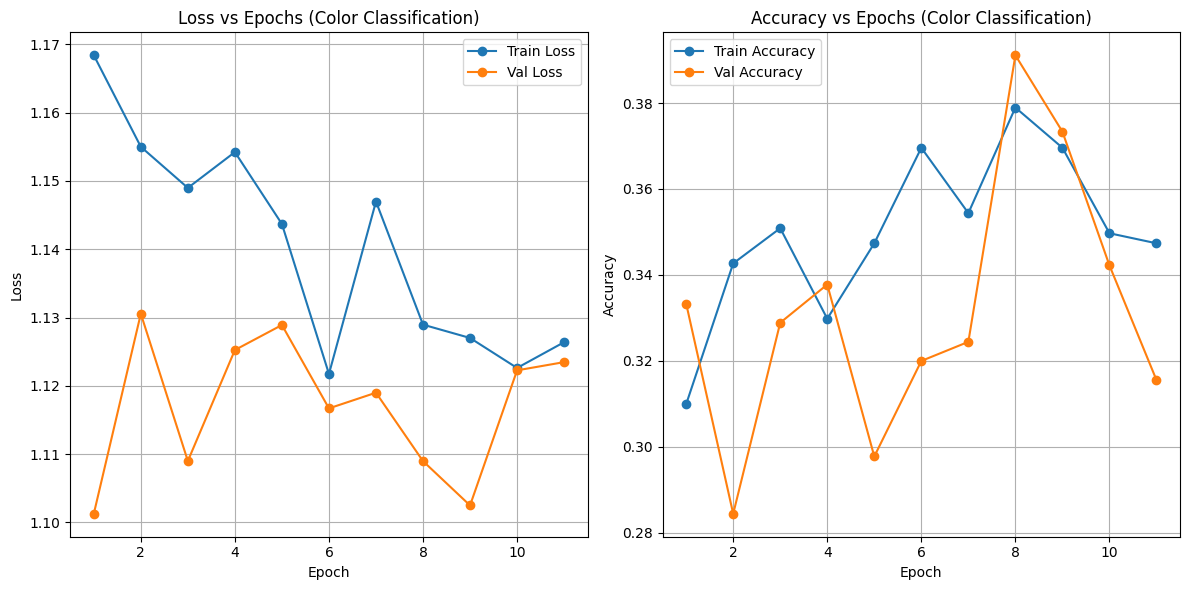

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 1) Simple TCN Model

class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=64, num_classes=3):
        super(TemporalConvNet, self).__init__()
        # Convolutional layers with pooling to reduce the temporal dimension
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = F.relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)  # shape: (batch_size, 256)
        
        x = F.relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)  # Final output
        return x


# 2) Dataset for Color Classification, using .vmrk files (Block 2)

class EEGColorDataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files from `data_dir`.
    For each file, the corresponding '.vmrk' file is read from `vmrk_dir` by
    replacing '_filtered_down.npy' with '.vmrk'. The .vmrk file is expected
    to contain stimulus lines in the format: "MkX=Stimulus,Code,...".
    
    Marker mapping (for Block 2):
      S23 -> yellow
      S21 and S210 -> blue
      S22 and S220 -> violet
      
    The first three occurrences for each stimulus marker are removed.
    If there’s still a mismatch between epochs and markers after filtering,
    the data is truncated.
    """
    def __init__(self, data_dir, vmrk_dir, file_list):
        super().__init__()
        self.X_all = []
        self.y_all = []
        
        # 1) Identify scenario from participant ID, e.g. "01_ln" => scenario 1, etc.
        self.id_to_scenario = {
            "01_ln": 1, "02gd": 2, "03as": 3, "04ep": 1, "05br": 2, "06nc": 3,
            "07fs": 1, "08am": 2, "09dm": 3, "10lc": 1, "11gb": 2, "12ag": 3,
            "13gc": 1, "14es": 2, "15kf": 3, "16gd": 1, "17st": 2, "18gf": 3,
            "19tm": 1, "20md": 2, "21es": 3, "22mc": 1, "23lp": 2, "24cs": 3,
            "25vt": 1, "26fs": 2, "27rv": 3, "28gv": 1, "29bc": 2, "30ss": 3
        }
        
        # 2) scenario -> marker_code -> color mapping for Block 2
        self.scenario_to_marker_color = {
            1: {
                "S23": "yellow",  # csm (no shock) => yellow
                "S21": "blue",    # csp_l => blue
                "S210": "blue",
                "S22": "violet",  # csp_r => violet
                "S220": "violet",
            },
            2: {
                "S23": "blue",
                "S21": "violet",
                "S210": "violet",
                "S22": "yellow",
                "S220": "yellow",
            },
            3: {
                "S23": "violet",
                "S21": "yellow",
                "S210": "yellow",
                "S22": "blue",
                "S220": "blue",
            }
        }
        
        # 3) color -> numeric label
        self.color_to_label = {"blue": 0, "yellow": 1, "violet": 2}
        
        # Allowed marker codes for block 2
        self.allowed_codes = ['S23', 'S21', 'S210', 'S22', 'S220']
        
        # 4) Process each file
        for fname in file_list:
            # Load the .npy data
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)  # shape: (n_epochs, n_channels, n_times)
            n_epochs = data_3d.shape[0]
            
            # Identify scenario from file prefix (e.g., "01_ln")
            participant_prefix = fname.split("_")[0]
            scenario = self.id_to_scenario.get(participant_prefix, 1)
            
            # Build the .vmrk file path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk for {fname} at {vmrk_path}, skipping.")
                continue
            
            # Parse markers from the .vmrk file with normalization to remove spaces
            marker_codes = self.parse_vmrk(vmrk_path)
            # Filter to keep only allowed codes
            marker_codes = [c for c in marker_codes if c in self.allowed_codes]
            # Remove the first three occurrences for each individual marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # If there’s still a mismatch, truncate to the smaller count
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # Convert marker codes to numeric labels using the scenario mapping
            scenario_map = self.scenario_to_marker_color[scenario]
            numeric_labels = [self.color_to_label[scenario_map[c]] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)
            self.y_all = np.concatenate(self.y_all, axis=0)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        """
        Reads each line in the .vmrk file that starts with 'Mk' and contains 'Stimulus'.
        Example: Mk2=Stimulus,S21,1234,1,0
        Extracts and returns the marker code (e.g. 'S21') for each valid line.
        Normalizes the marker code by removing any spaces.
        """
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    # Remove any spaces in the marker code so "S 21" becomes "S21"
                    code_str = parts[1].strip().replace(" ", "")
                    # Ensure the code has an "S" prefix
                    if not code_str.startswith("S"):
                        code_str = "S" + code_str
                    codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        """
        Removes the first three occurrences for each allowed marker code.
        Returns the filtered list of marker codes.
        """
        counts = {code: 0 for code in self.allowed_codes}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences of this marker
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        x_epoch = self.X_all[idx]  # shape: (n_channels, n_times)
        y_label = self.y_all[idx]  # numeric color label
        return torch.from_numpy(x_epoch).float(), torch.tensor(y_label, dtype=torch.long)


# 3) Training & Validation Helper Function

def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0.0
    avg_acc = correct / total if total > 0 else 0.0
    return avg_loss, avg_acc


# 4) Main Script

if __name__ == "__main__":
    data_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2"
    vmrk_dir = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"

    train_files = [
        "01_ln_block2_filtered_down.npy",
        "02gd_block2_filtered_down.npy",
        "03as_block2_filtered_down.npy",
        "04ep_block2_filtered_down.npy",
        "05br_block2_filtered_down.npy",
        "07fs_block2_filtered_down.npy",
        "08am_block2_filtered_down.npy",
        "09dm_block2_filtered_down.npy",
        "10lc_block2_filtered_down.npy",
        "11gb_block2_filtered_down.npy",
        "12ag_block2_filtered_down.npy",
        "13gc_block2_filtered_down.npy",
        "15kf_block2_filtered_down.npy",
        "16gd_block2_filtered_down.npy",
        "17st_block2_filtered_down.npy",
        "18gf_block2_filtered_down.npy",
        "19tm_block2_filtered_down.npy",
        "20md_block2_filtered_down.npy",
        "21es_block2_filtered_down.npy"
    ]
    val_files = [
        "23lp_block2_filtered_down.npy",
        "24cs_block2_filtered_down.npy",
        "25vt_block2_filtered_down.npy",
        "26fs_block2_filtered_down.npy",
        "27rv_block2_filtered_down.npy"
    ]
    test_files = [
        "28gv_block2_filtered_down.npy",
        "29bc_block2_filtered_down.npy",
        "30ss_block2_filtered_down.npy"
    ]
    
    # Create datasets
    train_dataset = EEGColorDataset(data_dir, vmrk_dir, train_files)
    val_dataset = EEGColorDataset(data_dir, vmrk_dir, val_files)
    test_dataset = EEGColorDataset(data_dir, vmrk_dir, test_files)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    # Inspect an example batch
    if len(train_loader) > 0:
        example_x, example_y = next(iter(train_loader))
        print("Example batch shape:", example_x.shape, example_y.shape)
        n_channels = example_x.shape[1]
    else:
        print("Warning: Train dataset is empty.")
        n_channels = 64  # fallback
    num_classes = 3
    
    # Instantiate and train the model
    model = TemporalConvNet(input_channels=n_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    n_epochs = 50
    patience = 10
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1} (best epoch was {best_epoch}, val_loss={best_val_loss:.4f})")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_color_model.pt")
    print("Model saved as tcn_block1_color_model.pt")
    
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs (Color Classification)')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs (Color Classification)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


Train dataset size: 855
Val dataset size:   225
Test dataset size:  135
Example batch shape: torch.Size([22, 64, 2250]) torch.Size([22])
TemporalConvNet(
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bat

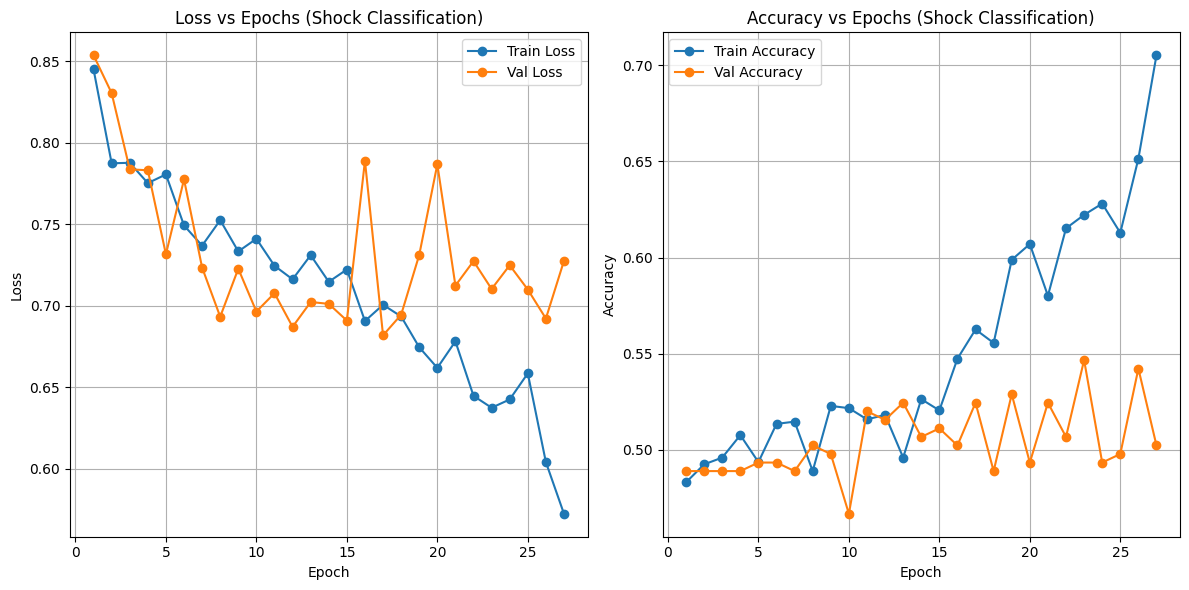

In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 1) Simple TCN Model

class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=64, num_classes=2):  # Updated default to 2 classes
        super(TemporalConvNet, self).__init__()
        # Convolutional layers with pooling to reduce the temporal dimension
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = F.relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)  # shape: (batch_size, 256)
        
        x = F.relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)  # Final output
        return x


# 2) Dataset for Shock Classification using .vmrk files (Block 2)

class EEGColorDataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files from `data_dir`.
    For each file, the corresponding '.vmrk' file is read from `vmrk_dir` by
    replacing '_filtered_down.npy' with '.vmrk'. The .vmrk file is expected
    to contain stimulus lines in the format: "MkX=Stimulus,Code,...".
    
    Original marker mapping for Block 2 was based on colors:
      S23 -> yellow
      S21 and S210 -> blue
      S22 and S220 -> violet
      
    Now we convert these markers into binary shock labels:
      Shock (CS+): S21 and S22  -> label 1
      No shock (CS−): S23, S210, and S220  -> label 0
      
    The first three occurrences for each stimulus marker are removed.
    If there’s still a mismatch between epochs and markers after filtering,
    the data is truncated.
    """
    def __init__(self, data_dir, vmrk_dir, file_list):
        super().__init__()
        self.X_all = []
        self.y_all = []
        
        # Mapping from allowed marker codes remains the same
        self.allowed_codes = ['S23', 'S21', 'S210', 'S22', 'S220']
        
        # Process each file
        for fname in file_list:
            # Load the .npy data
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)  # shape: (n_epochs, n_channels, n_times)
            n_epochs = data_3d.shape[0]
            
            # Build the .vmrk file path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk for {fname} at {vmrk_path}, skipping.")
                continue
            
            # Parse markers from the .vmrk file (normalize marker codes)
            marker_codes = self.parse_vmrk(vmrk_path)
            # Filter to keep only allowed codes
            marker_codes = [c for c in marker_codes if c in self.allowed_codes]
            # Remove the first three occurrences for each individual marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # If there’s still a mismatch, truncate to the smaller count
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # NEW: Convert marker codes to binary shock labels
            # 1 = shock (CS+): S21, S22
            # 0 = no shock (CS−): S23, S210, S220
            shock_mapping = {"S21": 1, "S22": 1, "S23": 0, "S210": 0, "S220": 0}
            numeric_labels = [shock_mapping[c] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)
            self.y_all = np.concatenate(self.y_all, axis=0)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        """
        Reads each line in the .vmrk file that starts with 'Mk' and contains 'Stimulus'.
        Example: Mk2=Stimulus,S21,1234,1,0
        Extracts and returns the marker code (e.g. 'S21') for each valid line.
        Normalizes the marker code by removing any spaces.
        """
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    # Remove any spaces in the marker code so "S 21" becomes "S21"
                    code_str = parts[1].strip().replace(" ", "")
                    # Ensure the code has an "S" prefix
                    if not code_str.startswith("S"):
                        code_str = "S" + code_str
                    codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        """
        Removes the first three occurrences for each allowed marker code.
        Returns the filtered list of marker codes.
        """
        counts = {code: 0 for code in self.allowed_codes}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences of this marker
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        x_epoch = self.X_all[idx]  # shape: (n_channels, n_times)
        y_label = self.y_all[idx]  # binary shock label (0 or 1)
        return torch.from_numpy(x_epoch).float(), torch.tensor(y_label, dtype=torch.long)


# 3) Training & Validation Helper Function

def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0.0
    avg_acc = correct / total if total > 0 else 0.0
    return avg_loss, avg_acc


# 4) Main Script

if __name__ == "__main__":
    data_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2"
    vmrk_dir = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"

    train_files = [
        "01_ln_block2_filtered_down.npy",
        "02gd_block2_filtered_down.npy",
        "03as_block2_filtered_down.npy",
        "04ep_block2_filtered_down.npy",
        "05br_block2_filtered_down.npy",
        "07fs_block2_filtered_down.npy",
        "08am_block2_filtered_down.npy",
        "09dm_block2_filtered_down.npy",
        "10lc_block2_filtered_down.npy",
        "11gb_block2_filtered_down.npy",
        "12ag_block2_filtered_down.npy",
        "13gc_block2_filtered_down.npy",
        "15kf_block2_filtered_down.npy",
        "16gd_block2_filtered_down.npy",
        "17st_block2_filtered_down.npy",
        "18gf_block2_filtered_down.npy",
        "19tm_block2_filtered_down.npy",
        "20md_block2_filtered_down.npy",
        "21es_block2_filtered_down.npy"
    ]
    val_files = [
        "23lp_block2_filtered_down.npy",
        "24cs_block2_filtered_down.npy",
        "25vt_block2_filtered_down.npy",
        "26fs_block2_filtered_down.npy",
        "27rv_block2_filtered_down.npy"
    ]
    test_files = [
        "28gv_block2_filtered_down.npy",
        "29bc_block2_filtered_down.npy",
        "30ss_block2_filtered_down.npy"
    ]
    
    # Create datasets
    train_dataset = EEGColorDataset(data_dir, vmrk_dir, train_files)
    val_dataset = EEGColorDataset(data_dir, vmrk_dir, val_files)
    test_dataset = EEGColorDataset(data_dir, vmrk_dir, test_files)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    # Inspect an example batch
    if len(train_loader) > 0:
        example_x, example_y = next(iter(train_loader))
        print("Example batch shape:", example_x.shape, example_y.shape)
        n_channels = example_x.shape[1]
    else:
        print("Warning: Train dataset is empty.")
        n_channels = 64  # fallback
    
    # Update number of classes to 2 for binary classification
    num_classes = 2
    model = TemporalConvNet(input_channels=n_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    n_epochs = 50
    patience = 10
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1} (best epoch was {best_epoch}, val_loss={best_val_loss:.4f})")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_color_model.pt")
    print("Model saved as tcn_block1_color_model.pt")
    
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs (Shock Classification)')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs (Shock Classification)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


Train dataset size: 855
Val dataset size:   225
Test dataset size:  135
Example batch shape: torch.Size([22, 64, 2250]) torch.Size([22])
TemporalConvNet(
  (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (batchnorm3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bat

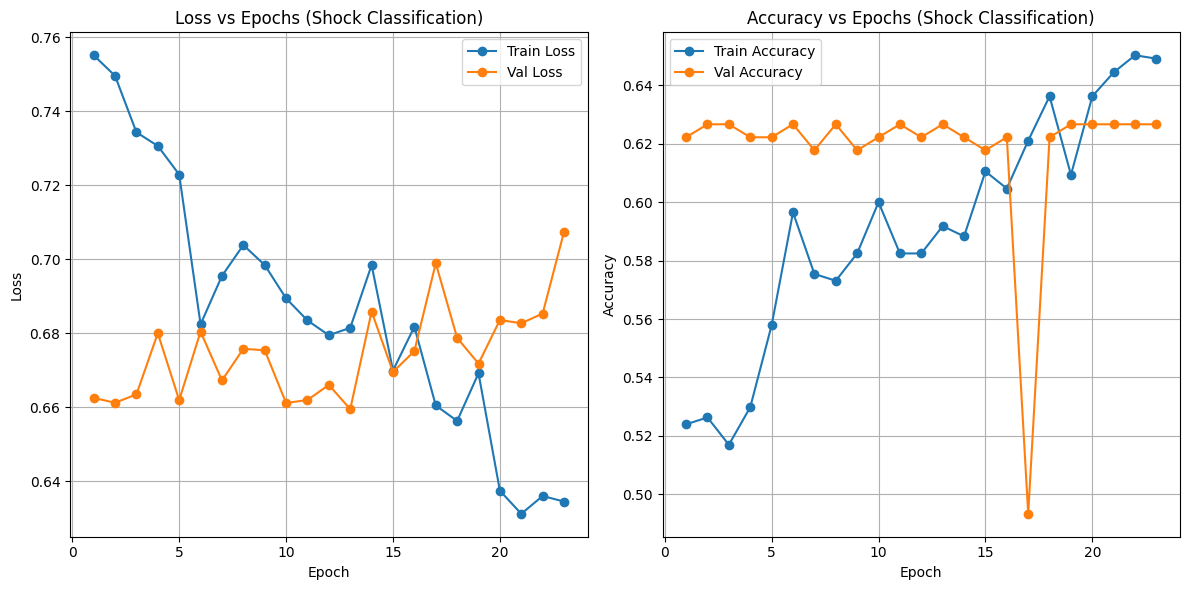

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 1) Simple TCN Model

class TemporalConvNet(nn.Module):
    def __init__(self, input_channels=64, num_classes=2):  # Updated default to 2 classes
        super(TemporalConvNet, self).__init__()
        # Convolutional layers with pooling to reduce the temporal dimension
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=5, padding=2)
        self.batchnorm1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.batchnorm2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv4 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm4 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.conv5 = nn.Conv1d(256, 256, kernel_size=5, padding=2)
        self.batchnorm5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Fully connected layers (MLP)
        self.fc1 = nn.Linear(256, 128)
        self.batchnorm_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 32)
        self.batchnorm_fc2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = F.relu(self.batchnorm1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.batchnorm2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.batchnorm3(self.conv3(x)))
        x = self.pool3(x)
        
        x = F.relu(self.batchnorm4(self.conv4(x)))
        x = self.pool4(x)
        
        x = F.relu(self.batchnorm5(self.conv5(x)))
        x = self.pool5(x)
        
        # Global average pooling over the time dimension
        x = torch.mean(x, dim=2)  # shape: (batch_size, 256)
        
        x = F.relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)  # Final output
        return x


# 2) Dataset for Shock Classification using .vmrk files (Block 2)

class EEGColorDataset(Dataset):
    """
    Loads multiple '*_filtered_down.npy' files from `data_dir`.
    For each file, the corresponding '.vmrk' file is read from `vmrk_dir` by
    replacing '_filtered_down.npy' with '.vmrk'. The .vmrk file is expected
    to contain stimulus lines in the format: "MkX=Stimulus,Code,...".
      
    Now we convert these markers into binary shock labels:
      Shock (CS+): S21 and S22  -> label 1
      No shock (CS−): S23, S210, and S220  -> label 0
      
    The first three occurrences for each stimulus marker are removed.
    If there’s still a mismatch between epochs and markers after filtering,
    the data is truncated.
    """
    def __init__(self, data_dir, vmrk_dir, file_list):
        super().__init__()
        self.X_all = []
        self.y_all = []
        
        # Mapping from allowed marker codes remains the same
        self.allowed_codes = ['S23', 'S21', 'S210', 'S22', 'S220']
        
        # Process each file
        for fname in file_list:
            # Load the .npy data
            npy_path = os.path.join(data_dir, fname)
            if not os.path.exists(npy_path):
                print(f"Warning: {fname} not found in {data_dir}, skipping.")
                continue
            data_3d = np.load(npy_path)  # shape: (n_epochs, n_channels, n_times)
            n_epochs = data_3d.shape[0]
            
            # Build the .vmrk file path
            base_name = fname.replace("_filtered_down.npy", "")
            vmrk_path = os.path.join(vmrk_dir, base_name + ".vmrk")
            if not os.path.exists(vmrk_path):
                print(f"Warning: No .vmrk for {fname} at {vmrk_path}, skipping.")
                continue
            
            # Parse markers from the .vmrk file (normalize marker codes)
            marker_codes = self.parse_vmrk(vmrk_path)
            # Filter to keep only allowed codes
            marker_codes = [c for c in marker_codes if c in self.allowed_codes]
            # Remove the first three occurrences for each individual marker
            filtered_marker_codes = self.filter_marker_codes(marker_codes)
            
            # If there’s still a mismatch, truncate to the smaller count
            if len(filtered_marker_codes) != n_epochs:
                min_len = min(n_epochs, len(filtered_marker_codes))
                print(f"Warning: Mismatch in {fname}: data has {n_epochs} epochs, but after filtering found {len(filtered_marker_codes)} markers. Truncating to {min_len}.")
                data_3d = data_3d[:min_len]
                filtered_marker_codes = filtered_marker_codes[:min_len]
            
            # NEW: Convert marker codes to binary shock labels
            # 1 = shock (CS+): S21, S22, S229, S210
            # 0 = no shock (CS−): S23
            shock_mapping = {"S21": 1, "S22": 1, "S23": 0, "S210": 1, "S220": 1}
            numeric_labels = [shock_mapping[c] for c in filtered_marker_codes]
            numeric_labels = np.array(numeric_labels, dtype=int)
            
            self.X_all.append(data_3d)
            self.y_all.append(numeric_labels)
        
        if len(self.X_all) > 0:
            self.X_all = np.concatenate(self.X_all, axis=0)
            self.y_all = np.concatenate(self.y_all, axis=0)
        else:
            self.X_all = np.array([])
            self.y_all = np.array([])
    
    def parse_vmrk(self, vmrk_path):
        """
        Reads each line in the .vmrk file that starts with 'Mk' and contains 'Stimulus'.
        Example: Mk2=Stimulus,S21,1234,1,0
        Extracts and returns the marker code (e.g. 'S21') for each valid line.
        Normalizes the marker code by removing any spaces.
        """
        codes = []
        with open(vmrk_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("Mk") and "Stimulus" in line:
                    parts = line.split(',')
                    if len(parts) < 2:
                        continue
                    # Remove any spaces in the marker code so "S 21" becomes "S21"
                    code_str = parts[1].strip().replace(" ", "")
                    # Ensure the code has an "S" prefix
                    if not code_str.startswith("S"):
                        code_str = "S" + code_str
                    codes.append(code_str)
        return codes
    
    def filter_marker_codes(self, marker_codes):
        """
        Removes the first three occurrences for each allowed marker code.
        Returns the filtered list of marker codes.
        """
        counts = {code: 0 for code in self.allowed_codes}
        filtered = []
        for code in marker_codes:
            if counts[code] < 3:
                counts[code] += 1
                continue  # Skip the first three occurrences of this marker
            else:
                counts[code] += 1
                filtered.append(code)
        return filtered
    
    def __len__(self):
        return self.X_all.shape[0]
    
    def __getitem__(self, idx):
        x_epoch = self.X_all[idx]  # shape: (n_channels, n_times)
        y_label = self.y_all[idx]  # binary shock label (0 or 1)
        return torch.from_numpy(x_epoch).float(), torch.tensor(y_label, dtype=torch.long)


# 3) Training & Validation Helper Function

def run_epoch(model, dataloader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in dataloader:
        if optimizer:
            optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if optimizer:
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += len(batch_y)
    avg_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0.0
    avg_acc = correct / total if total > 0 else 0.0
    return avg_loss, avg_acc


# 4) Main Script

if __name__ == "__main__":
    data_dir = r"D:\Per Patient Normalization Filtering Output without the first 3 trials downsampling to 500 HZ block 2"
    vmrk_dir = r"C:\Users\Asus\Documents\Professor Francesca Starita\.vmrk files"

    train_files = [
        "01_ln_block2_filtered_down.npy",
        "02gd_block2_filtered_down.npy",
        "03as_block2_filtered_down.npy",
        "04ep_block2_filtered_down.npy",
        "05br_block2_filtered_down.npy",
        "07fs_block2_filtered_down.npy",
        "08am_block2_filtered_down.npy",
        "09dm_block2_filtered_down.npy",
        "10lc_block2_filtered_down.npy",
        "11gb_block2_filtered_down.npy",
        "12ag_block2_filtered_down.npy",
        "13gc_block2_filtered_down.npy",
        "15kf_block2_filtered_down.npy",
        "16gd_block2_filtered_down.npy",
        "17st_block2_filtered_down.npy",
        "18gf_block2_filtered_down.npy",
        "19tm_block2_filtered_down.npy",
        "20md_block2_filtered_down.npy",
        "21es_block2_filtered_down.npy"
    ]
    val_files = [
        "23lp_block2_filtered_down.npy",
        "24cs_block2_filtered_down.npy",
        "25vt_block2_filtered_down.npy",
        "26fs_block2_filtered_down.npy",
        "27rv_block2_filtered_down.npy"
    ]
    test_files = [
        "28gv_block2_filtered_down.npy",
        "29bc_block2_filtered_down.npy",
        "30ss_block2_filtered_down.npy"
    ]
    
    # Create datasets
    train_dataset = EEGColorDataset(data_dir, vmrk_dir, train_files)
    val_dataset = EEGColorDataset(data_dir, vmrk_dir, val_files)
    test_dataset = EEGColorDataset(data_dir, vmrk_dir, test_files)
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size:   {len(val_dataset)}")
    print(f"Test dataset size:  {len(test_dataset)}")
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=22, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=22, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=22, shuffle=False)
    
    # Inspect an example batch
    if len(train_loader) > 0:
        example_x, example_y = next(iter(train_loader))
        print("Example batch shape:", example_x.shape, example_y.shape)
        n_channels = example_x.shape[1]
    else:
        print("Warning: Train dataset is empty.")
        n_channels = 64  # fallback
    
    # Update number of classes to 2 for binary classification
    num_classes = 2
    model = TemporalConvNet(input_channels=n_channels, num_classes=num_classes)
    print(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    n_epochs = 50
    patience = 10
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(n_epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1} (best epoch was {best_epoch}, val_loss={best_val_loss:.4f})")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}")
    
    torch.save(model.state_dict(), "tcn_block1_color_model.pt")
    print("Model saved as tcn_block1_color_model.pt")
    
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs_range, val_losses, 'o-', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs (Shock Classification)')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy')
    plt.plot(epochs_range, val_accuracies, 'o-', label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs (Shock Classification)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
